# Évaluation à l'échelle globale

In [1]:
import logging
import os
import sys

import numpy as np

_path = '/Odyssey/private/p23leflo/projects/4dvarnet-global-mapping'
if _path not in sys.path:
    sys.path.append(_path)

from src.mod_plot import *
from src.mod_stat import *
from src.mod_spectral import *
from src.mod_interp import *

logger = logging.getLogger()
logger.setLevel(logging.INFO)

## Paramètres

À modifier et à adapter pour chaque _mapping_ à évaluer :

In [2]:
method_name = 'unet_unrolling_5iter_grad_downsampling'
method_path = (
    '/Odyssey/private/p23leflo/projects/4dvarnet-global-mapping/inference/output/unet_unrolling_5iter_grad_downsampling_inference-to4th-stdinit0.10-niter5-wnoise0.20.nc'
)

# Méthode d'interpolation à utiliser pour le regrillage du mapping ;
# grille à utiliser pour la réinterpolation (chemin vers un fichier
# netCDF4 avec les mêmes noms de dimensions que le mapping)
interpolation_method = 'cubic'

# Appliquer le masque des terres si le mapping à évaluer n'en contient
# pas déjà
apply_mask = True

Paramètres génériques, pas trop besoin de modifier (normalement) :

In [3]:
time_min = '2018-12-31'
time_max = '2020-01-01'
output_dir = './results'

# Échelles spatiales (en km) pour le filtrage du signal
lambda_min = 65.
lambda_max = 500.

# Longueur le long de la trace (en km) à considérer pour l'analyse
# spectrale
segment_length = 1000.

lat_max = 80
lat_min = -80

# output statistical and spectral analysis filename
stat_output_filename = f'{output_dir}/stat_sla_{method_name}.nc'
psd_output_filename = f'{output_dir}/psd_sla_{method_name}.nc'

In [4]:
os.system(f'mkdir -p {output_dir}')
os.system(f'rm -f {stat_output_filename}')
os.system(f'rm -f {psd_output_filename}')

0

## Données

### Référence (Saral/AltiKa)

In [5]:
ds_alg = xr.open_dataset('/Odyssey/public/data_challenge_ssh_ose/data/independent_alongtrack/masked-alg-inter_duacs_miost_neurost.nc')
ds_alg[['sla_unfiltered']]

<xarray.Dataset> Size: 226MB
Dimensions:         (time: 14138044)
Coordinates:
  * time            (time) datetime64[ns] 113MB 2019-01-01T00:04:18.619014144...
Data variables:
    sla_unfiltered  (time) float64 113MB ...

### _Mapping_ à évaluer

In [6]:
if method_path.endswith('.nc'):
    ds_maps = (
        xr.open_dataset(method_path)
        .sel(time=slice(time_min, time_max))
        [['sla']]
    )

    resolution = (ds_maps.longitude[1] - ds_maps.longitude[0]).item()
    ds_maps = (
        ds_maps
        .pad(
            pad_width=dict(longitude=1),
            mode='wrap',
        )
        .assign(longitude=np.concatenate((
            [ds_maps.longitude[0].item() - resolution,],
            ds_maps.longitude.values,
            [ds_maps.longitude[-1].item() + resolution,],
        )))
    )

    ds_maps.longitude.attrs['units'] = 'degrees_east'
    ds_maps.latitude.attrs['units'] = 'degress_north'
else:  # DUACS, MIOST & NeurOST sont divisés en plusieurs fichiers
    ds_maps = (
        xr.open_mfdataset(
            f'{method_path}/*.nc',
            combine='nested',
            concat_dim='time',
        )
        .sel(time=slice(time_min, time_max))
        [['sla']]
    )

ds_maps

<xarray.Dataset> Size: 3GB
Dimensions:    (time: 367, latitude: 640, longitude: 1441)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2018-12-31 2019-01-01 ... 2020-01-01
  * latitude   (latitude) float64 5kB -78.88 -78.62 -78.38 ... 80.38 80.62 80.88
  * longitude  (longitude) float64 12kB -0.125 0.125 0.375 ... 359.6 359.9 360.1
Data variables:
    sla        (time, latitude, longitude) float64 3GB 0.08294 ... 0.08438

Réinterpolation du _mapping_ :

In [7]:
if interpolation_method:
    ds_maps = (
        ds_maps
        .interp(
            coords=dict(
                latitude=np.arange(ds_maps.latitude[0], ds_maps.latitude[-1], 1/12),
                longitude=np.arange(ds_maps.longitude[0], ds_maps.longitude[-1] , 1/12),
            ),
            method=interpolation_method,
        )
    )
    ds_maps

In [8]:
if (lat_max is not None) or (lat_min is not None):
    ds_maps = ds_maps.sel(latitude=slice(lat_min, lat_max))

In [9]:
ds_maps.sla.isnull().any().item()

False

In [10]:
ds_maps.longitude.attrs['units'] = 'degrees_east'
ds_maps.latitude.attrs['units'] = 'degrees_north'

## Interpolation du _mapping_ le long de la trace Saral/Altika

In [11]:
ds_interp = run_interpolation(ds_maps, ds_alg)
ds_interp = ds_interp.dropna('time')
ds_interp

2026-05-18 15:43:59 INFO     fetch data from 2018-12-31 00:00:00 to 2019-02-01 00:00:00


<xarray.Dataset> Size: 1GB
Dimensions:            (time: 14138044)
Coordinates:
  * time               (time) datetime64[ns] 113MB 2019-01-01T00:04:18.619014...
Data variables: (12/13)
    cycle              (time) float32 57MB 126.0 126.0 126.0 ... 136.0 136.0
    track              (time) float32 57MB 9.0 9.0 9.0 9.0 ... 408.0 408.0 408.0
    sla_unfiltered     (time) float64 113MB 0.074 0.071 0.121 ... 0.056 0.01
    sla_filtered       (time) float64 113MB 0.066 0.066 0.073 ... 0.031 0.027
    dac                (time) float64 113MB 0.343 0.344 0.344 ... 0.171 0.172
    ocean_tide         (time) float64 113MB -0.104 -0.104 ... -0.304 -0.314
    ...                 ...
    lwe                (time) float64 113MB -0.017 -0.016 -0.016 ... 0.014 0.016
    mdt                (time) float64 113MB -0.134 -0.136 ... -1.138 -1.154
    tpa_correction     (time) float64 113MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    longitude          (time) float64 113MB 63.49 63.4 63.31 ... 246.6 246.3
    la

2026-05-18 15:44:01 INFO     fetch data from 2019-01-31 00:00:00 to 2019-03-01 00:00:00
2026-05-18 15:44:03 INFO     fetch data from 2019-02-28 00:00:00 to 2019-04-01 00:00:00
2026-05-18 15:44:05 INFO     fetch data from 2019-03-31 00:00:00 to 2019-05-01 00:00:00
2026-05-18 15:44:06 INFO     fetch data from 2019-04-30 00:00:00 to 2019-06-01 00:00:00
2026-05-18 15:44:09 INFO     fetch data from 2019-05-31 00:00:00 to 2019-07-01 00:00:00
2026-05-18 15:44:10 INFO     fetch data from 2019-06-30 00:00:00 to 2019-08-01 00:00:00
2026-05-18 15:44:13 INFO     fetch data from 2019-07-31 00:00:00 to 2019-09-01 00:00:00
2026-05-18 15:44:15 INFO     fetch data from 2019-08-31 00:00:00 to 2019-10-01 00:00:00
2026-05-18 15:44:16 INFO     fetch data from 2019-09-30 00:00:00 to 2019-11-01 00:00:00
2026-05-18 15:44:18 INFO     fetch data from 2019-10-31 00:00:00 to 2019-12-01 00:00:00
2026-05-18 15:44:20 INFO     fetch data from 2019-11-30 00:00:00 to 2020-01-01 00:00:00


<xarray.Dataset> Size: 1GB
Dimensions:            (time: 14138044)
Coordinates:
  * time               (time) datetime64[ns] 113MB 2019-01-01T00:04:18.619014...
Data variables: (12/13)
    cycle              (time) float32 57MB 126.0 126.0 126.0 ... 136.0 136.0
    track              (time) float32 57MB 9.0 9.0 9.0 9.0 ... 408.0 408.0 408.0
    sla_unfiltered     (time) float64 113MB 0.074 0.071 0.121 ... 0.056 0.01
    sla_filtered       (time) float64 113MB 0.066 0.066 0.073 ... 0.031 0.027
    dac                (time) float64 113MB 0.343 0.344 0.344 ... 0.171 0.172
    ocean_tide         (time) float64 113MB -0.104 -0.104 ... -0.304 -0.314
    ...                 ...
    lwe                (time) float64 113MB -0.017 -0.016 -0.016 ... 0.014 0.016
    mdt                (time) float64 113MB -0.134 -0.136 ... -1.138 -1.154
    tpa_correction     (time) float64 113MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    longitude          (time) float64 113MB 63.49 63.4 63.31 ... 246.6 246.3
    latitude           (time) float64 113MB 70.51 70.57 70.62 ... -69.32 -69.55
    msla_interpolated  (time) float64 113MB 0.142 0.1418 ... 0.02521 0.03248

Nombre de points attendus : 14 138 044

In [13]:
print(f">>> Nombre de points interpolés : {ds_interp.time.size}")

>>> Nombre de points interpolés : 14138044


## Calcul de métriques

### Métriques statistiques

In [14]:
compute_stat_scores(
    ds_interp, lambda_min, lambda_max, stat_output_filename,method_name,
)

2026-05-18 15:44:47 INFO     Compute mapping error all scales
2026-05-18 15:44:47 INFO     Compute mapping error for scales between 65.0 and 500.0 km


Total RMSE= 0.07574112747694345 m
Total RMSE score= 0.4175494500164669 m


2026-05-18 15:45:44 INFO     Compute binning statistics
2026-05-18 15:46:01 INFO     Compute statistics by oceanic regime


FileNotFoundError: [Errno 2] No such file or directory: '/Odyssey/private/p23leflo/projects/4dvarnet-global-mapping/data/sad/land_water_mask_60.nc'

In [15]:
bias = (
    ds_interp.msla_interpolated
    - (ds_interp.sla_unfiltered - ds_interp.lwe)
).mean().item()

print(f"Biais global : {bias*1e3:.3} mm")

Biais global : 0.266 mm


FileNotFoundError: [Errno 2] No such file or directory: '/Odyssey/private/p23leflo/projects/4dvarnet-global-mapping/figures/Maps_unet_unrolling_5iter_grad_downsampling_errvar_glob.png'

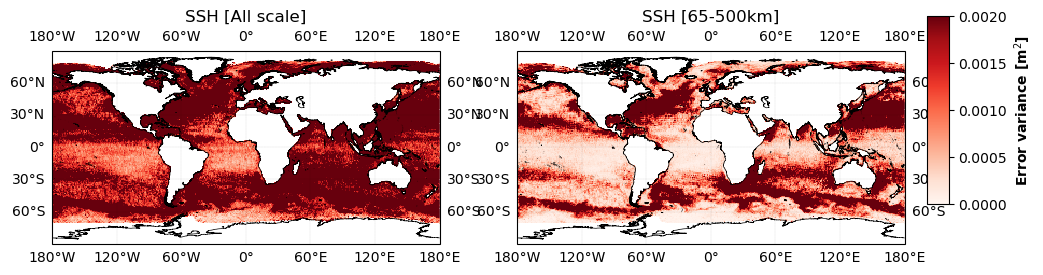

In [16]:
plot_stat_score_map_png(stat_output_filename)

In [16]:
plot_stat_by_regimes(stat_output_filename)

,mapping_err_var [m²],mapping_err_rms,sla_unfiltered_var [m²],sla_unfiltered_rms,mapping_err_filtered_var [m²],mapping_err_filtered_rms,sla_filtered_var [m²],sla_filtered_rms,var_score_allscale,var_score_filtered,rmse_score_allscale,rmse_score_filtered
coastal,0.002476,0.049776,0.008293,0.120239,0.000528,0.022968,0.001827,0.042742,0.701406,0.711226,0.586024,0.462634
offshore_highvar,0.002190,0.046854,0.053256,0.251278,0.000589,0.024278,0.021748,0.147479,0.958884,0.972898,0.813537,0.835382
offshore_lowvar,0.001151,0.033927,0.006310,0.114624,0.000214,0.014621,0.001783,0.042222,0.817680,0.880075,0.704011,0.653698
equatorial_band,0.001402,0.037538,0.005954,0.120330,0.000305,0.017460,0.000530,0.023029,0.764500,0.425158,0.688044,0.241845
arctic,0.002184,0.046786,0.007052,0.115946,0.000418,0.020453,0.001048,0.032371,0.690262,0.600674,0.596483,0.368186
antarctic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
plot_stat_by_regimes(stat_output_filename)[[
    'var_score_allscale', 'var_score_filtered',
    'rmse_score_allscale', 'rmse_score_filtered',
]]

,var_score_allscale,var_score_filtered,rmse_score_allscale,rmse_score_filtered
coastal,0.701406,0.711226,0.586024,0.462634
offshore_highvar,0.958884,0.972898,0.813537,0.835382
offshore_lowvar,0.817680,0.880075,0.704011,0.653698
equatorial_band,0.764500,0.425158,0.688044,0.241845
arctic,0.690262,0.600674,0.596483,0.368186
antarctic,NaN,NaN,NaN,NaN


### Métriques spectrales

In [18]:
compute_psd_scores_v2(
    ds_interp, psd_output_filename, lenght_scale=segment_length,
    method_name=method_name,
)

2026-03-01 22:22:42 INFO     Segment computation...
2026-03-01 22:22:47 INFO     Spectral analysis...
2026-03-01 22:26:20 INFO     Saving ouput...
2026-03-01 22:26:24 INFO     PSD file saved as: ./results/psd_sla_fdvarUnet-no-lwe.nc


Averaged effective resolution: 207.93481002904068 km


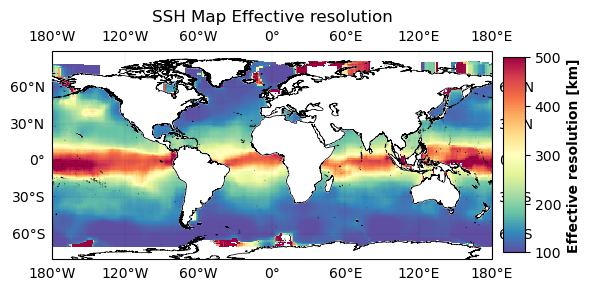

In [19]:
plot_effective_resolution_png(psd_output_filename)